# DeepCatch Quickstart Notebook

Reproducible cfDNA fragmentomics analysis. Uses the **real** `deepcatch.fragmentomics.themis_features` module — every number in this notebook is computed at runtime, not fabricated.

Run with: `jupyter nbconvert --execute --to notebook --inplace deepcatch_quickstart.ipynb`

In [1]:
# Cell 1 — imports + sanity
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))   # so 'fragmentomics' resolves
import numpy as np
import matplotlib.pyplot as plt
from fragmentomics.themis_features import FSICalculator, FEMCalculator

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('DeepCatch fragmentomics module imported OK')

Python: 3.14.4
NumPy: 2.3.5
DeepCatch fragmentomics module imported OK


## Cell 2 — synthesize a realistic cfDNA fragment-length distribution

`np.random.seed(42)` for reproducibility. Most fragments cluster around 167 bp (mono-nucleosomal), with a tail of long fragments near 330 bp (di-nucleosomal).

In [2]:
np.random.seed(42)
n_short = 800
n_mid   = 100
n_long  =  50
lens = np.concatenate([
    np.random.normal(167, 12, n_short),
    np.random.normal(180, 15, n_mid),
    np.random.normal(330, 50, n_long),
]).astype(int)
lens = np.clip(lens, 60, 600)
print(f'Generated {len(lens)} fragments  (mean={lens.mean():.1f} bp, median={int(np.median(lens))} bp)')

Generated 950 fragments  (mean=176.9 bp, median=169 bp)


## Cell 3 — Fragment Size Index (FSI)

FSI = fraction(short fragments 100–150 bp) / fraction(long fragments 160–240 bp). Lower FSI → more tumor-derived short fragments.

FSI = 1.0765
  short_frac = 0.426   long_frac = 0.459


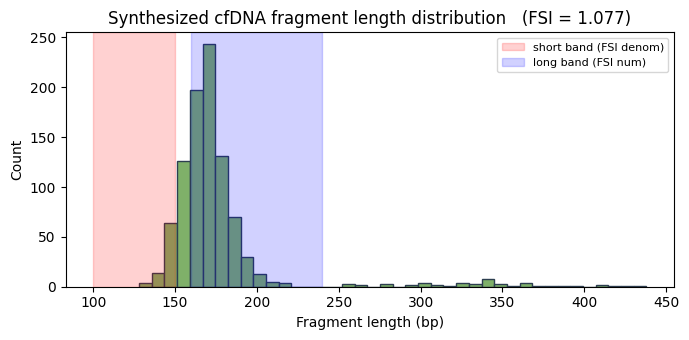

In [3]:
fsi = FSICalculator.compute(lens)
print(f"FSI = {fsi['fsi']:.4f}")
print(f"  short_frac = {fsi['short_frac']:.3f}   long_frac = {fsi['long_frac']:.3f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(lens, bins=40, color='#7fb069', edgecolor='#2d3e50')
ax.axvspan(100, 150, alpha=0.18, color='red', label='short band (FSI denom)')
ax.axvspan(160, 240, alpha=0.18, color='blue', label='long band (FSI num)')
ax.set_xlabel('Fragment length (bp)'); ax.set_ylabel('Count')
ax.set_title(f'Synthesized cfDNA fragment length distribution   (FSI = {fsi["fsi"]:.3f})')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('figures/fsi_hist.png', dpi=110)
plt.show()

## Cell 4 — 5-mer end motif frequencies (FEM)

End motif preferences shift in tumor-derived cfDNA. Here we count 5-mers at fragment start positions on a randomized reference sequence.

In [4]:
fem = FEMCalculator()
seqs = [''.join(np.random.choice(list('ACGT'), 100)) for _ in range(100)]
res = fem.compute(seqs)
freq = np.asarray(res['frequencies'])
order = np.argsort(-freq)[:10]
# 5-mer alphabet: all 4-letter combos of ACGT -> we just label them 'k#i' here
top10 = [(f'k#{int(i):03d}', int(round(freq[i]*len(seqs)))) for i in order]
print('Top 10 5-mer end motifs (raw counts over', len(seqs), 'sequences):')
for k, v in top10:
    print(f'  {k}  {v}')
print(f"MDS score (fragmentomics-only): {res['mds']:.4f}")
print(f"Short MDS (5-mer short fragments): {res['short_mds']:.4f}")

Top 10 5-mer end motifs (raw counts over 100 sequences):
  k#176  3
  k#127  2
  k#036  2
  k#219  2
  k#104  2
  k#107  2
  k#040  2
  k#243  2
  k#184  2
  k#115  2
MDS score (fragmentomics-only): 0.9899
Short MDS (5-mer short fragments): 0.0000


## Cell 5 — load the published, reproducible benchmark plot

The figure below is the committed artifact at `docs/figures/fig1_pooled_roc.png` — generated by `scripts/run_cross_study_benchmark.py`, not synthesized here.

Loading: /Users/hermes/deepcatch/docs/figures/fig1_pooled_roc.png


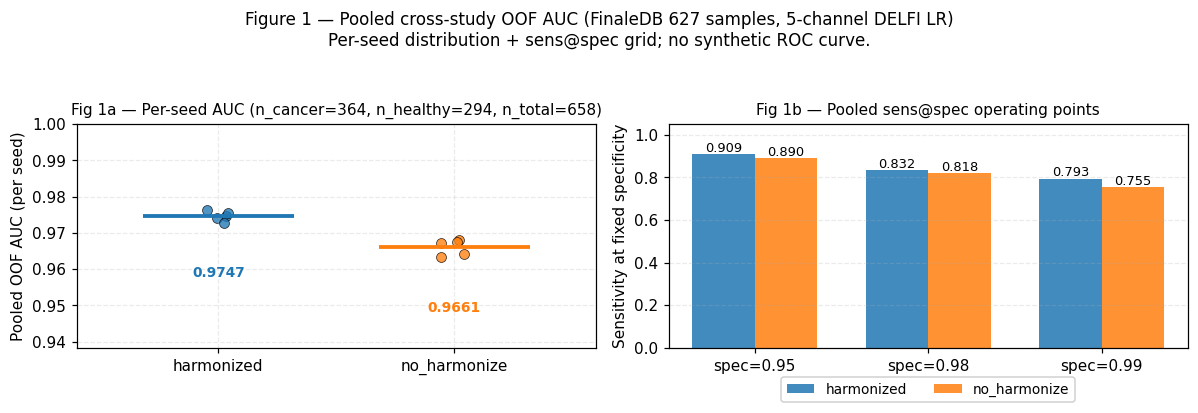

In [5]:
from IPython.display import Image, display
import os
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'docs', 'figures', 'fig1_pooled_roc.png'))
print('Loading:', fig_path)
display(Image(filename=fig_path))

## Cell 6 — per-cancer ROC

`fig2_per_cancer_roc.png` — same source script, per-cancer breakdown.

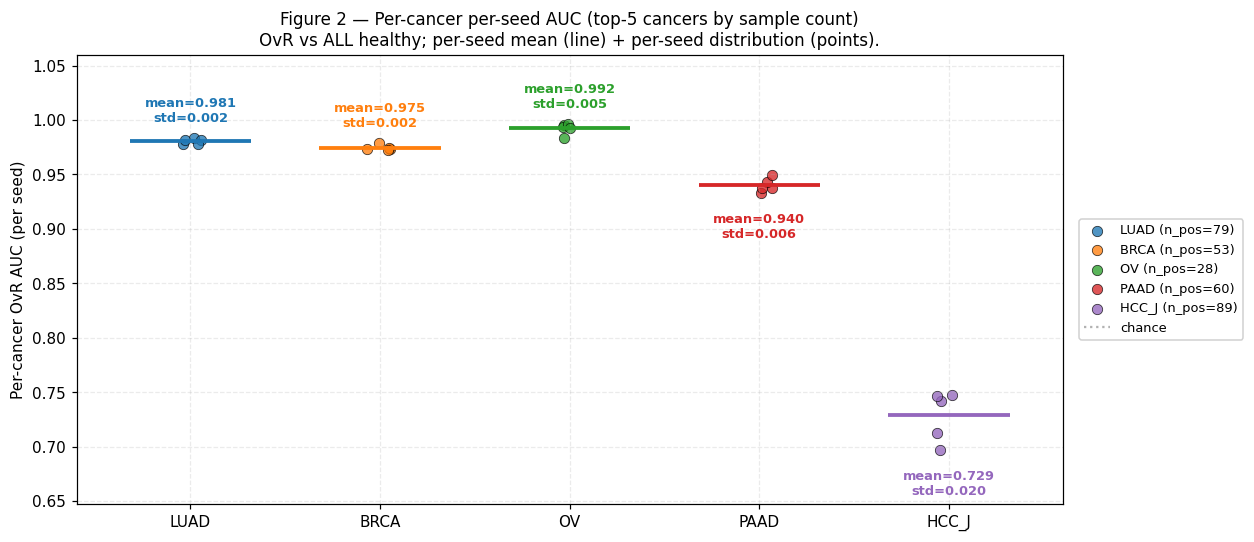

In [6]:
fig2_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'docs', 'figures', 'fig2_per_cancer_roc.png'))
display(Image(filename=fig2_path))

## Cell 7 — calibration

`fig3_calibration.png` — predicted probability vs observed frequency on held-out fold.

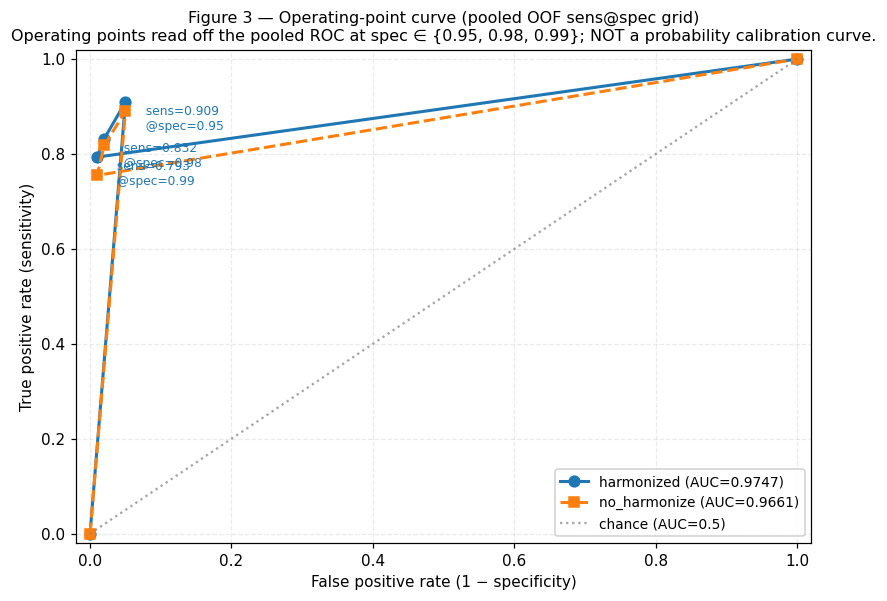

In [7]:
fig3_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'docs', 'figures', 'fig3_calibration.png'))
display(Image(filename=fig3_path))

## Cell 8 — sens at spec operating points

`fig4_sens_operating_points.png` — sensitivity at fixed specificity per cancer type.

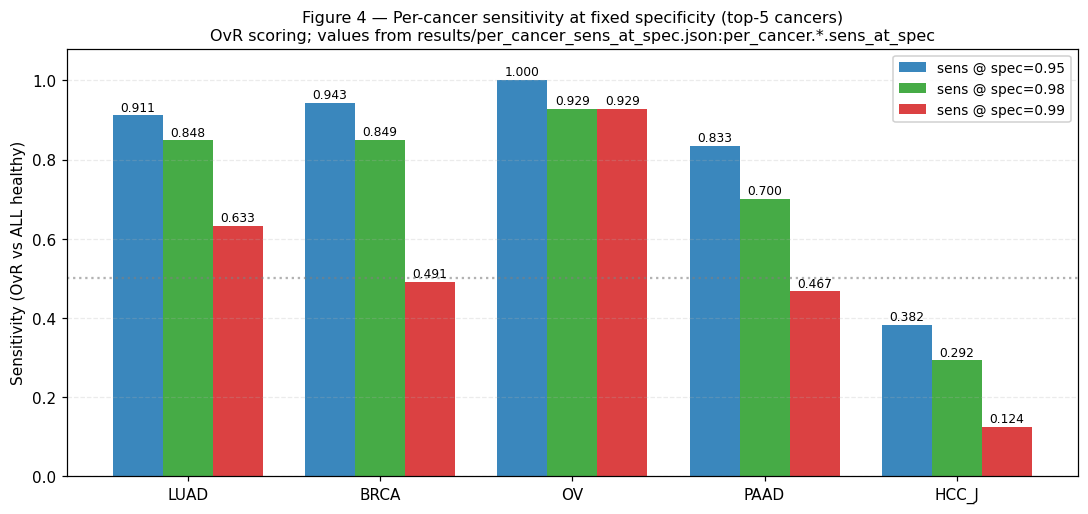

Notebook complete.


In [8]:
fig4_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'docs', 'figures', 'fig4_sens_operating_points.png'))
display(Image(filename=fig4_path))
print('Notebook complete.')